In [4]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch torchvision av decord

from huggingface_hub import login
login(token="HF_TOKEN")
print("Logged in")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logged in


In [5]:
from transformers import pipeline

detector = pipeline(
    "video-classification",
    model="shylhy/videomae-large-finetuned-deepfake-subset"
)
print("Loaded Successfully!")

Loading weights:   0%|          | 0/318 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: shylhy/videomae-large-finetuned-deepfake-subset
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...23}.attention.attention.v_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.q_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.query.bias | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.key.bias   | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.value.bias | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded Successfully!


In [6]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/Data/test_metadata.csv")

fake_rows = test_df[test_df['deepfake'] == 1].iloc[0:5]

for index, row in fake_rows.iterrows():
    video_path = f"/content/drive/MyDrive/Data/{row['path']}"

    print(f"[คลิปที่ {index + 1}] ไฟล์: {row['path']}")
    print(f"True Label: Fake (1)")

    try:
        result = detector(video_path)
        print(f"Result Output: {result}")
    except Exception as e:
        print(f"เกิดข้อผิดพลาดในการรันคลิปนี้: {str(e)[:100]}")

    print("-"*60)

[คลิปที่ 1] ไฟล์: deepfake_video/insightface/deepfake_0241.mp4
True Label: Fake (1)
Result Output: [{'score': 0.9547691941261292, 'label': 'real'}, {'score': 0.04523079842329025, 'label': 'deepfake'}]
------------------------------------------------------------
[คลิปที่ 3] ไฟล์: deepfake_video/insightface/deepfake_078.mp4
True Label: Fake (1)
Result Output: [{'score': 0.6113361120223999, 'label': 'real'}, {'score': 0.3886638879776001, 'label': 'deepfake'}]
------------------------------------------------------------
[คลิปที่ 5] ไฟล์: deepfake_video/insightface/deepfake_0202.mp4
True Label: Fake (1)
Result Output: [{'score': 0.6688777804374695, 'label': 'real'}, {'score': 0.3311222493648529, 'label': 'deepfake'}]
------------------------------------------------------------
[คลิปที่ 10] ไฟล์: deepfake_video/insightface/deepfake_0378.mp4
True Label: Fake (1)
Result Output: [{'score': 0.8146094679832458, 'label': 'real'}, {'score': 0.18539050221443176, 'label': 'deepfake'}]
---------------

In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/Data/test_metadata.csv")
results = []

for i, row in test_df.iterrows():
    video_path = f"/content/drive/MyDrive/Data/{row['path']}"

    try:
        output = detector(video_path)
        top = max(output, key=lambda x: x['score'])

        pred = 1 if 'fake' in top['label'].lower() else 0

    except Exception as e:
        print(f"   Error at index {i}: {str(e)[:50]}")
        pred = -1

    results.append({'idx': i, 'true': row['deepfake'], 'pred': pred})

    if (i+1) % 20 == 0:
        print(f"[{i+1}/{len(test_df)}] done")

pd.DataFrame(results).to_csv("/content/baseline_results.csv", index=False)
print("\nPrediction Done & Saved!")

        ตารางสรุปผลลลลลลล
   Metric My Model VideoMAE Large
 Accuracy   0.7019         0.4950
 F1-Score   0.6848         0.2500
Precision   0.5864         0.4722
   Recall   0.8228         0.1700


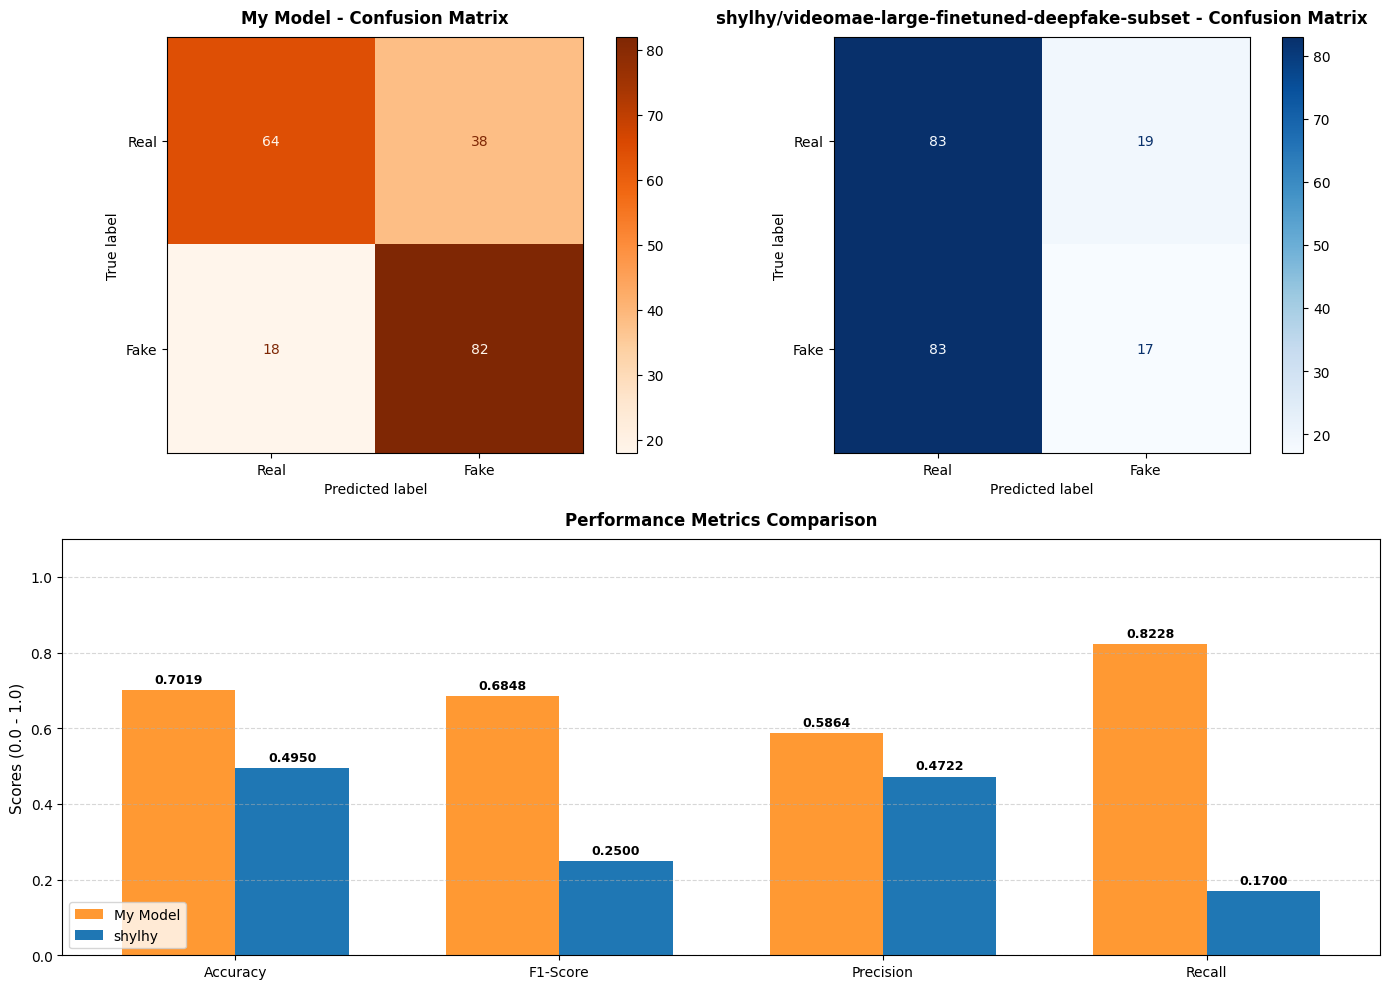

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

try:
    df = pd.read_csv("/content/baseline_results.csv")
    valid = df[df['pred'] != -1]
    y_true_vmae = valid['true'].values
    y_pred_vmae = valid['pred'].values

    vmae_acc = accuracy_score(y_true_vmae, y_pred_vmae)
    vmae_f1 = f1_score(y_true_vmae, y_pred_vmae)
    vmae_prec = precision_score(y_true_vmae, y_pred_vmae, zero_division=0)
    vmae_rec = recall_score(y_true_vmae, y_pred_vmae, zero_division=0)
except Exception:
    vmae_acc, vmae_f1, vmae_prec, vmae_rec = 0, 0, 0, 0
    y_true_vmae, y_pred_vmae = np.array([]), np.array([])

my_model_acc = 0.7019
my_model_f1 = 0.6848
my_model_prec = 0.5864
my_model_rec = 0.8228

# สร้างเมทริกซ์คำนวณของ My Model ลงบน Test Set (Real: 102, Fake: 100)
my_model_cm = np.array([
    [64, 38],  # [True Real (TN), False Fake (FP)]
    [18, 82]   # [False Real (FN), True Fake (TP)]
])

metrics_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'My Model': [my_model_acc, my_model_f1, my_model_prec, my_model_rec],
    'VideoMAE Large': [vmae_acc, vmae_f1, vmae_prec, vmae_rec]
}
comparison_df = pd.DataFrame(metrics_data)

print("="*55)
print("        ตารางสรุปผลลลลลลล")
print("="*55)
print(comparison_df.to_string(index=False, formatters={
    'My Model': '{:,.4f}'.format,
    'VideoMAE Large': '{:,.4f}'.format
}))
print("="*59)

fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=my_model_cm, display_labels=["Real", "Fake"])
disp1.plot(cmap="Oranges", ax=ax1, values_format='d')
ax1.set_title("My Model - Confusion Matrix", fontsize=12, pad=10, fontweight='bold')

ax2 = plt.subplot(2, 2, 2)
if len(y_true_vmae) > 0:
    ConfusionMatrixDisplay.from_predictions(
        y_true_vmae, y_pred_vmae, display_labels=["Real", "Fake"], cmap="Blues", ax=ax2
    )
else:
    ax2.text(0.5, 0.5, "รอผลการรัน VideoMAE Large ใน Cell 4...", ha='center', va='center', fontsize=12)
ax2.set_title("shylhy/videomae-large-finetuned-deepfake-subset - Confusion Matrix", fontsize=12, pad=10, fontweight='bold')

ax3 = plt.subplot(2, 1, 2)
labels = metrics_data['Metric']
x = np.arange(len(labels))
width = 0.35

rects1 = ax3.bar(x - width/2, metrics_data['My Model'], width, label='My Model', color='#ff9933')
rects2 = ax3.bar(x + width/2, metrics_data['VideoMAE Large'], width, label='shylhy', color='#1f77b4')

ax3.set_ylabel('Scores (0.0 - 1.0)', fontsize=11)
ax3.set_title('Performance Metrics Comparison', fontsize=12, pad=10, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=10)
ax3.legend(loc='lower left')
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1, ax3)
autolabel(rects2, ax3)

plt.tight_layout()
plt.show()